**Instructions**

* Read and complete all exercises below in the provided `.qmd` notebook (or `.ipynb` file if you prefer)
* Feel free to convert to `.ipynb` if you prefer via `quarto convert svm-lab.qmd`

**Submission:**

* You need to upload ONE document to Canvas when you are done. 
* A PDF (or HTML) of the completed form of this notebook
* The final uploaded version should NOT have any code-errors present. 
* All outputs must be visible in the uploaded version, including code-cell outputs, images, graphs, etc

## Demonstration

ISLR and/or ISLP provided demonstration content for SVM chapter (see ISLR website)

## Assignment 

`Question-1: Conceptual` (ISLP chapter-9, page 396)

Here we explore the maximal margin classifier on a toy data set.

(a) We are given $n=7$ observations in $p=2$ dimensions. For each observation, there is an associated class label.

| Obs. | $X_1$ | $X_2$ | $Y$ |
| :---: | :---: | :---: | :---: |
| 1 | 3 | 4 | Red |
| 2 | 2 | 2 | Red |
| 3 | 4 | 4 | Red |
| 4 | 1 | 4 | Red |
| 5 | 2 | 1 | Blue |
| 6 | 4 | 3 | Blue |
| 7 | 4 | 1 | Blue |

Sketch the observations.


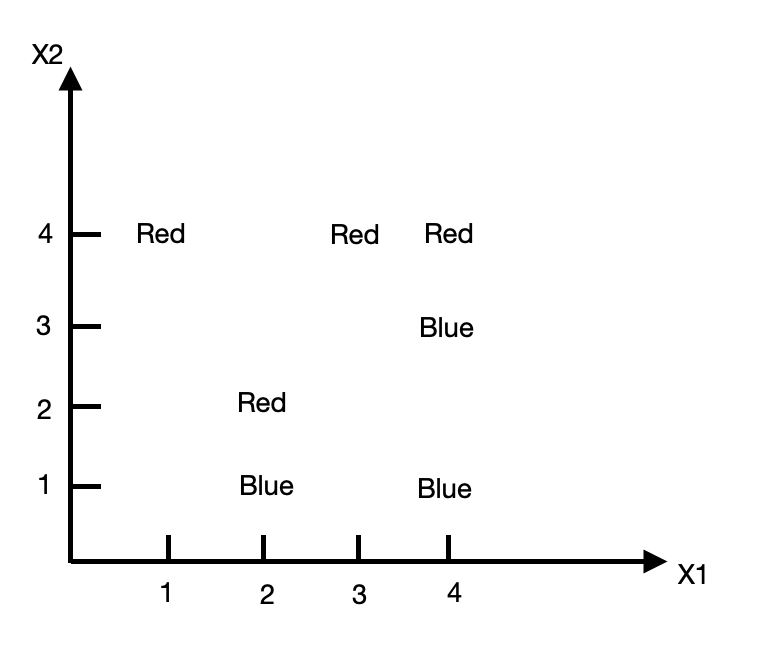

(b) Sketch the optimal separating hyperplane, and provide the equation for this hyperplane (of the form (9.1)).

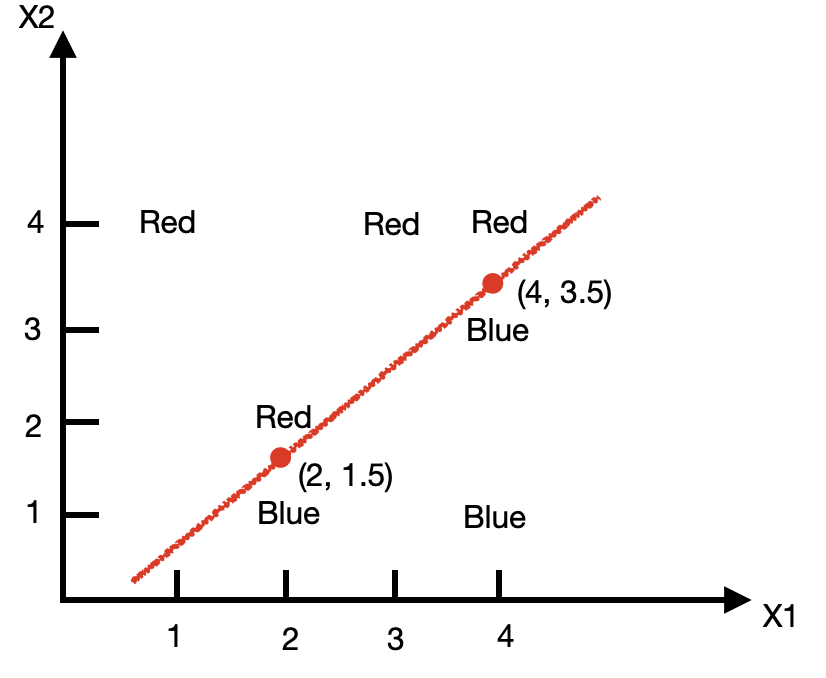

The separating hyperpline passes points (2, 1.5) and (4, 3.5). These 2 points are the middle points of lower left Red and Blue, and the upper right Red and Blue. These 2 pairs of Red and Blue observations are closest to each other. In order to separate them, we need to draw a line that crosses the middle of them.
Line function: $X_2 = \beta_0 + \beta_1 * X_1$
Slope $\beta_1 = (3.5 - 1.5)/ (4-2) = 1$
$1.5 = \beta_0 + 2$
$3.5 = \beta_0 + 4$
$\beta_0 = -0.5$

The hyperpline equation is $\boxed{-0.5 + X_1 - X_2 = 0}$

c) Describe the classification rule for the maximal margin classifier. It should be something along the lines of "Classify to Red if $\beta_0+\beta_1 X_1+\beta_2 X_2>0$, and classify to Blue otherwise." Provide the values for $\beta_0, \beta_1$, and $\beta_2$.

**Answer:**
The classficiation rule for the maximal margin classifier is 
Classify to Red if $\beta_0 + \beta_1 * X_1 + \beta_2 * X_2$ > 0, and classify to Blue otherwise, where $\beta_0 = -0.5; \beta_1 = 1; \beta_2 = -1$

(d) On your sketch, indicate the margin for the maximal margin hyperplane.

**Answer:**
(1) For the maximal margin classifier, the margin is the region between the two parallel lines that touch the closest observations (The Red point immediate above the hyperplane (2, 2)and the Blue point (4, 3) immediate below the hyperplane) on each side of the separating hyperplane. The margin lines are the as dashed lines on the sketch.
(2) Calculte the margin lines:

$X_2 = \beta_{0_M1} + \beta_{1_M1} * X_1$
Known: slope $\beta_{1_M1} = 1$; $X_1 = 2$; $X_2 = 2$ 
Get: 2 = $\beta_{0_M1} + 1 *2 \Rightarrow$ $\beta_{0_M1} = 0$
So, the upper margin line is: $\boxed{X_1 - X_2 = 0}$
__

$X_2 = \beta_{0_M2} + \beta_{1_M2} * X_1$
Known: slope $\beta_{1_M2} = 1$; $X_1 = 4$; $X_2 = 3$ 
Get: 3 = $\beta_{0_M2} + 1 *4 \Rightarrow$ $\beta_{0_M2} = -1$
So, the lower margin line is: $\boxed{X_1 - X_2 = 1}$

(3) Calculate the margin:
Hyperplane: $X_1 - X_2 = 0.5$
Upper margin: $X_1 - X_2 = 0$
Lower margin: $X_1 - X_2 = 1$
$\text{distance} = \frac{|c|}{\sqrt{\beta_1^2 + \beta_2^2}}$
$|c| = 0.5; \sqrt{\beta_1^2 + \beta_2^2} = \sqrt{2} \Rightarrow$ 
$\boxed{Margin = \frac{0.5}{\sqrt{2}}}$

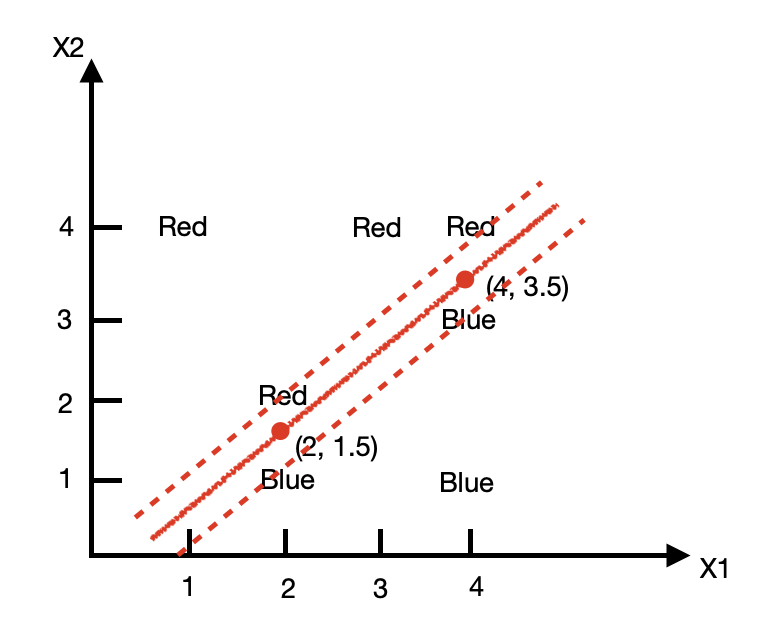


(e) Indicate the support vectors for the maximal margin classifier.


**Answer:** Support vectors are the observations that lie exactly on the margin boundaries, including
Red (2,2)
Red (4,4)
Blue (2,1)
Blue (4,3)



(f) Argue that a slight movement of the seventh observation would not affect the maximal margin hyperplane.


**Answer:** Only the observations that are close the hyperplane might affect it. The seventh observation Blue (4,1)'s distance is far away from the hyperplane, so a slight movement would not affect the maximal margin hyperplane.

(g) Sketch a hyperplane that is not the optimal separating hyperplane, and provide the equation for this hyperplane.


Below shows a non-optimal separating hyperplane with 2 observations mis-classified. The equation of this hyperplane is: $X_2 = 3.5$
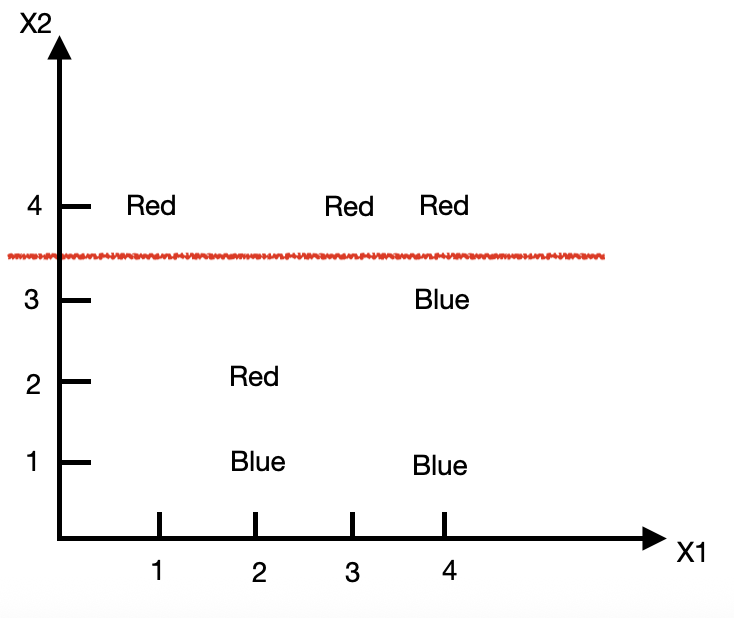

(h) Draw an additional observation on the plot so that the two classes are no longer separable by a hyperplane.

**Ansswer:** Adding the new Red observation at (4, 2) will make it difficult to draw a linear hyperplane that separates two classes. 
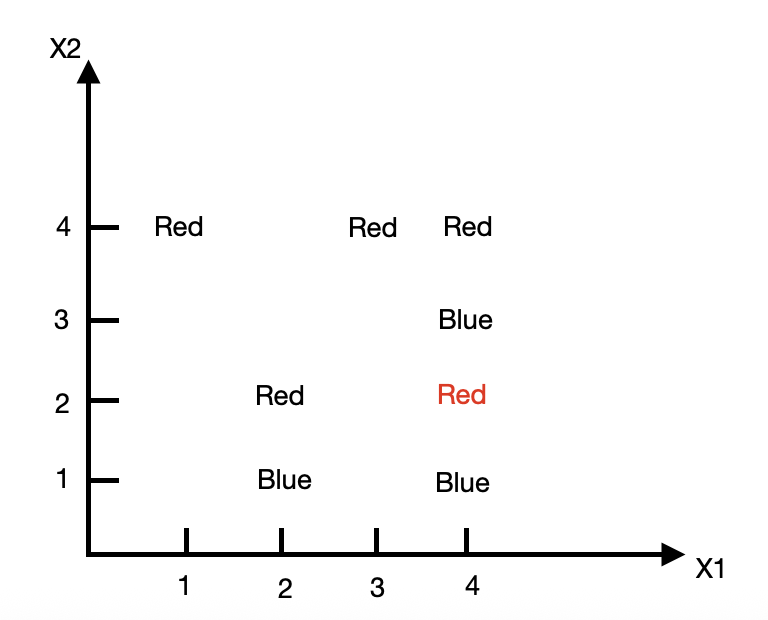


`Question-2: Applied` (ISLP chapter-9, page 397)

We have seen that we can fit an SVM with a non-linear kernel in order to perform classification using a non-linear decision boundary. We will now see that we can also obtain a non-linear decision boundary by performing logistic regression using non-linear transformations of the features.

(a) Generate a data set with $n=500$ and $p=2$, such that the observations belong to two classes with a quadratic decision boundary between them. For instance, you can do this as follows:

```
rng = np.random.default_rng(5)
x1 = rng.uniform(size=500) - 0.5
x2 = rng.uniform(size=500) - 0.5
y = x1**2 - x2**2 > 0
```


In [2]:
import numpy as np
rng = np.random.default_rng(5)
x1 = rng.uniform(size=500) - 0.5
x2 = rng.uniform(size=500) - 0.5
y = x1**2 - x2**2 > 0


(b) Plot the observations, colored according to their class labels. Your plot should display $X_1$ on the $x$-axis, and $X_2$ on the $y$ axis.

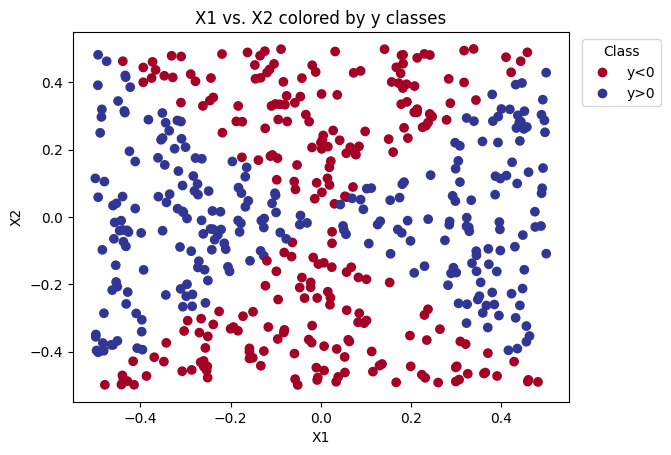

In [69]:
import matplotlib.pyplot as plt

scatter_plot = plt.scatter(x1, x2, c = y, cmap='RdYlBu')
handles, values = scatter_plot.legend_elements()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('X1 vs. X2 colored by y classes')
plt.legend(handles, ['y<0','y>0'], title='Class', loc='upper right',bbox_to_anchor=(1.2,1))
plt.show()

(c) Fit a logistic regression model to the data, using $X_1$ and $X_2$ as predictors.

In [22]:
import statsmodels.api as sm
x = np.array([x1,x2]).T
x = sm.add_constant(x)
logit_model = sm.Logit(y, x)
logit_model_result = logit_model.fit()
logit_model_result.summary()

Optimization terminated successfully.
         Current function value: 0.692711
         Iterations 3


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  500
Model:                          Logit   Df Residuals:                      497
Method:                           MLE   Df Model:                            2
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:               0.0005256
Time:                        09:21:07   Log-Likelihood:                -346.36
converged:                       True   LL-Null:                       -346.54
Covariance Type:            nonrobust   LLR p-value:                    0.8335
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0221      0.090      0.246      0.805      -0.154       0.198
x1            -0.1662      0.308     -0.540      0.589      -0.769       0.437
x2             0.0901      0.306      0.294      0.769      -0.510       0.691
==============================================================================
"""

(d) Apply this model to the training data in order to obtain a predicted class label for each training observation. Plot the observations, colored according to the predicted class labels. The decision boundary should be linear.

In [56]:
# train test split
from sklearn.model_selection import train_test_split
x = np.array([x1,x2]).T
x_train, x_val, y_train, y_val = train_test_split(
  x, y,
  test_size = 0.2,
  random_state=42,
  shuffle=True
)

# fit logistic regression using train data
x_train_constant = sm.add_constant(x_train)
logit_model = sm.Logit(y_train, x_train_constant)
logit_model_result = logit_model.fit()

# predict y
pred = logit_model_result.predict(x_train_constant)
pred_class = pred>0.5

Optimization terminated successfully.
         Current function value: 0.691470
         Iterations 4


Text(0.5, 1.0, 'x1 vs. x2 and predicted class in training data')

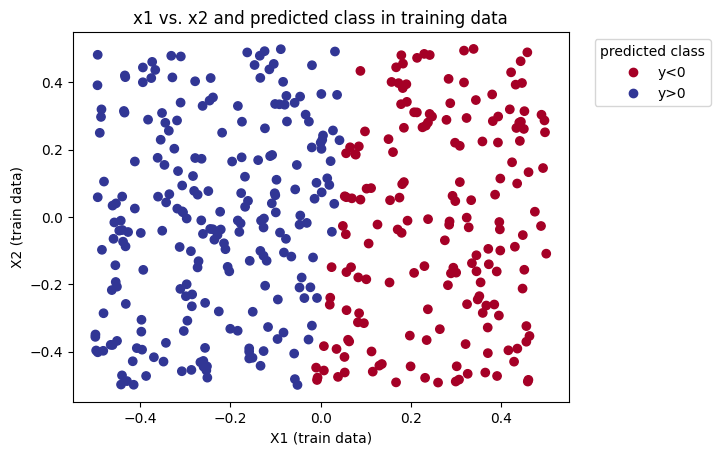

In [64]:
# plot obsevations and colored by pred class
import matplotlib.pyplot as plt

scatter_plot = plt.scatter(x_train[:,0], x_train[:,1], c = pred_class, cmap='RdYlBu')
handles, _ = scatter_plot.legend_elements()
plt.xlabel('X1 (train data)')
plt.ylabel('X2 (train data)')
plt.legend(handles, ['y<0', 'y>0'], title='predicted class', loc='upper right', bbox_to_anchor = (1.3, 1))
plt.title('x1 vs. x2 and predicted class in training data')

(e) Now fit a logistic regression model to the data using non-linear functions of $X_1$ and $X_2$ as predictors (e.g. $X_1^2, X_1 \times X_2, \log \left(X_2\right)$, and so forth).



In [92]:
# create non-linear predictors X1*X2
import pandas as pd

x = pd.DataFrame({'x1': x1,
                  'x2': x2,
                  'x1*x2': x1*x2})

# fit logistic regression model using new predictors
x_constant = sm.add_constant(x)
logit_model_multiply = sm.Logit(y, x_constant)
logit_model_multiply_result = logit_model_multiply.fit()

# print result
logit_model_multiply_result.summary()

Optimization terminated successfully.
         Current function value: 0.692709
         Iterations 3


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  500
Model:                          Logit   Df Residuals:                      496
Method:                           MLE   Df Model:                            3
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:               0.0005283
Time:                        15:12:58   Log-Likelihood:                -346.35
converged:                       True   LL-Null:                       -346.54
Covariance Type:            nonrobust   LLR p-value:                    0.9471
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0219      0.090      0.244      0.807      -0.154       0.198
x1            -0.1658      0.308     -0.539      0.590      -0.769       0.437
x2             0.0908      0.307      0.296      0.767      -0.510       0.692
x1*x2          0.0448      1.029      0.044      0.965      -1.972       2.061
==============================================================================
"""

(f) Apply this model to the training data in order to obtain a predicted class label for each training observation. Plot the observations, colored according to the predicted class labels. The decision boundary should be obviously non-linear. If it is not, then repeat (a)-(e) until you come up with an example in which the predicted class labels are obviously non-linear.

In [93]:
# train test split
from sklearn.model_selection import train_test_split

x = pd.DataFrame({'x1': x1,
                  'x2': x2,
                  'x1*x2': x1*x2})
x_train, x_val, y_train, y_val = train_test_split(
  x, y,
  test_size = 0.2,
  random_state=42,
  shuffle=True
)

# fit logistic regression using train data
x_train_constant = sm.add_constant(x_train)
logit_model = sm.Logit(y_train, x_train_constant)
logit_model_result = logit_model.fit()

# predict y
pred = logit_model_result.predict(x_train_constant)
pred_class = pred>0.5

Optimization terminated successfully.
         Current function value: 0.691455
         Iterations 4


Text(0.5, 1.0, 'x1 vs. x1*x2 and predicted class in training data')

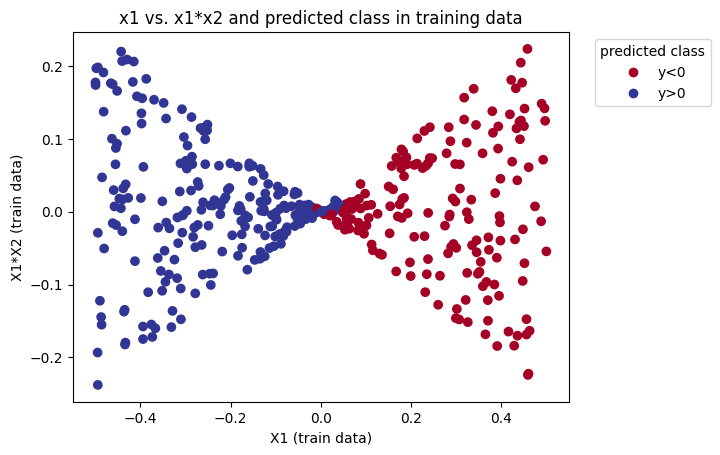

In [97]:
# plot obsevations and colored by pred class
import matplotlib.pyplot as plt

scatter_plot = plt.scatter(x_train[['x1']], x_train[['x1*x2']], c = pred_class, cmap='RdYlBu')
handles, _ = scatter_plot.legend_elements()
plt.xlabel('X1 (train data)')
plt.ylabel('X1*X2 (train data)')
plt.legend(handles, ['y<0', 'y>0'], title='predicted class', loc='upper right', bbox_to_anchor = (1.3, 1))
plt.title('x1 vs. x1*x2 and predicted class in training data')

(g) Fit a support vector classifier to the data with $X_1$ and $X_2$ as predictors. Obtain a class prediction for each training observation. Plot the observations, colored according to the predicted class labels.


(h) Fit a SVM using a non-linear kernel to the data. Obtain a class prediction for each training observation. Plot the observations, colored according to the predicted class labels.

(i) Comment on your results.